# Applied AI Mastery — Module 1: The Basics (Minimalist Perspective)
### A hands-on NumPy companion notebook

__Rina Buoy, PhD__

This notebook walks through **every concept** in Module 1 and demonstrates each one
in code, so the math stops being abstract. We cover four pillars:

1. **Minimum Statistics** — describing data
2. **Minimum Probability** — reasoning under uncertainty
3. **Linear Algebra** — the building blocks of data
4. **Vector Calculus** — the engine that trains models

Everything is built on `numpy`. We use `matplotlib` only to *see* the ideas.

> **How to read it:** run the cells top to bottom. Each section has a short
> explanation followed by a runnable demonstration that prints or plots the result.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility — fix the random seed so every run gives the same numbers.
rng = np.random.default_rng(42)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
print("Setup complete. NumPy version:", np.__version__)

Setup complete. NumPy version: 1.26.4


---
# Part 1 — Minimum Statistics

## 1.1 Sample vs. Population

- **Population**: the *entire* group you care about (every possible data point).
- **Sample**: a manageable subset drawn from the population.
- **Inference**: using the sample to estimate facts about the population.

In machine learning the population is usually unknowable (e.g. *all* possible
customers), so we work with a sample and *infer*. Below we create a fake
"population", draw a sample from it, and see how close the sample mean lands to
the true population mean.

> **Slide question:** *Are the customer data used to build a credit-score model a
> sample or a population?* They are a **sample** — you only ever see the customers
> you have, not every possible borrower, and you hope the patterns generalize.

In [18]:
# Pretend this is the WHOLE population (10,000 people's annual income, in $1000s)
population = rng.normal(loc=55, scale=15, size=10_000)

# We can rarely measure everyone, so we draw a sample of 100
sample = rng.choice(population, size=100, replace=False)

print(f"Population size : {population.size:,}")
print(f"Sample size     : {sample.size:,}")
print(f"Population mean  (mu)   : {population.mean():.2f}")
print(f"Sample mean      (x-bar): {sample.mean():.2f}")
print(f"Inference error         : {abs(population.mean() - sample.mean()):.2f}")

Population size : 10,000
Sample size     : 100
Population mean  (mu)   : 54.85
Sample mean      (x-bar): 56.67
Inference error         : 1.83


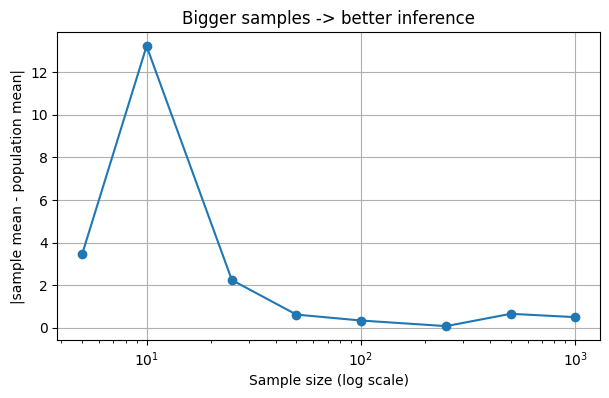

In [19]:
# As the sample grows, the sample mean converges toward the population mean.
sizes = [5, 10, 25, 50, 100, 250, 500, 1000]
errors = []
for n in sizes:
    s = rng.choice(population, size=n, replace=False)
    errors.append(abs(s.mean() - population.mean()))

plt.plot(sizes, errors, "o-")
plt.xscale("log")
plt.xlabel("Sample size (log scale)")
plt.ylabel("|sample mean - population mean|")
plt.title("Bigger samples -> better inference")
plt.show()

## 1.2 Descriptive Statistics

We summarise a dataset with three families of numbers:

| Family | Measures | Question answered |
|---|---|---|
| **Central tendency** | mean, median, mode | Where is the "middle"? |
| **Variability** | variance, standard deviation | How spread out is it? |
| **Position** | percentiles | Where does a value rank? |

We'll take each in turn.

### Mean (arithmetic average)

$$\mu = \frac{1}{N}\sum_{i=1}^{N} x_i \qquad\text{(population)}\qquad
   \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i \quad\text{(sample)}$$

The formula is identical; only the symbol and the population/sample interpretation
differ. The mean is **highly sensitive to outliers** — one extreme value drags it.

In [20]:
data = np.array([4, 8, 15, 16, 23, 42])

manual_mean = data.sum() / data.size
print("Manual mean :", manual_mean)
print("np.mean     :", np.mean(data))

# Outlier sensitivity: add one billionaire to a list of normal incomes
incomes = np.array([40, 45, 50, 55, 60])
with_outlier = np.append(incomes, 100_000)
print("\nMean without outlier:", incomes.mean())
print("Mean WITH   outlier :", with_outlier.mean(), "  <- destroyed by one value")

Manual mean : 18.0
np.mean     : 18.0

Mean without outlier: 50.0
Mean WITH   outlier : 16708.333333333332   <- destroyed by one value


### Median

The **middle** value once the data is sorted.

- If $n$ is **odd**: the value at position $\frac{n+1}{2}$.
- If $n$ is **even**: the average of the values at positions $\frac{n}{2}$ and $\frac{n}{2}+1$.

It is **robust** — outliers barely move it. That same billionaire above changes the
mean by thousands but the median by almost nothing.

In [21]:
def median_from_scratch(x):
    s = np.sort(x)
    n = s.size
    if n % 2 == 1:                       # odd -> single middle element
        return s[(n - 1) // 2]
    mid = n // 2                          # even -> average the two middles
    return (s[mid - 1] + s[mid]) / 2

odd  = np.array([1, 3, 3, 6, 7, 8, 9])           # slide example -> 6
even = np.array([1, 2, 3, 4, 5, 6, 8, 9])        # slide example -> 4.5

print("odd  median (scratch / numpy):", median_from_scratch(odd),  np.median(odd))
print("even median (scratch / numpy):", median_from_scratch(even), np.median(even))

print("\nRobustness check:")
print("median without outlier:", np.median(incomes))
print("median WITH   outlier :", np.median(with_outlier), "  <- barely moved")

odd  median (scratch / numpy): 6 6.0
even median (scratch / numpy): 4.5 4.5

Robustness check:
median without outlier: 50.0
median WITH   outlier : 52.5   <- barely moved


### Mode

The value (or values) that appears **most frequently**. There is no formula — you
just count. A dataset can be *unimodal*, *multimodal*, or have *no mode*.
NumPy has no built-in `mode`, so we count with `np.unique`.

In [22]:
def mode(x):
    values, counts = np.unique(x, return_counts=True)
    top = counts.max()
    modes = values[counts == top]        # could be more than one
    return modes, top

samples = np.array([2, 2, 3, 4, 5, 5, 5, 6, 7, 8])
modes, freq = mode(samples)
print(f"Mode(s): {modes}  (each appears {freq} times)")

multi = np.array([1, 1, 2, 3, 3])
print("Multimodal example ->", mode(multi)[0])

Mode(s): [5]  (each appears 3 times)
Multimodal example -> [1 3]


### Variance and Standard Deviation

**Variance** = the average squared distance from the mean.

$$\sigma^2 = \frac{1}{N}\sum (x_i-\mu)^2 \quad(\text{population}) \qquad
   s^2 = \frac{1}{n-1}\sum (x_i-\bar{x})^2 \quad(\text{sample})$$

The sample version divides by $n-1$ (**Bessel's correction**) to remove bias.
In NumPy this is the `ddof` ("delta degrees of freedom") argument:
`ddof=0` for population, `ddof=1` for sample.

**Standard deviation** is just $\sqrt{\text{variance}}$ — it returns the spread to
the *original units* of the data.

In [23]:
x = np.array([2, 4, 4, 4, 5, 5, 7, 9], dtype=float)
mu = x.mean()

pop_var_manual = np.mean((x - mu) ** 2)
sam_var_manual = np.sum((x - mu) ** 2) / (x.size - 1)

print("Population variance: manual =", pop_var_manual, "| numpy =", np.var(x, ddof=0))
print("Sample     variance: manual =", sam_var_manual, "| numpy =", np.var(x, ddof=1))
print()
print("Population std dev:", np.std(x, ddof=0))
print("Sample     std dev:", np.std(x, ddof=1))

Population variance: manual = 4.0 | numpy = 4.0
Sample     variance: manual = 4.571428571428571 | numpy = 4.571428571428571

Population std dev: 2.0
Sample     std dev: 2.138089935299395


### Percentiles

The **$k$-th percentile** is the value below which $k\%$ of the data falls.
Rank-to-value uses the index $i = \frac{k}{100}\times n$; value-to-rank uses

$$\text{percentile rank of } x = \frac{\#\{\text{values below } x\}}{n}\times 100.$$

In [24]:
scores = np.array([2, 2, 3, 4, 5, 5, 5, 6, 7, 8, 8, 8, 8, 8, 9, 9, 10, 11, 11, 12])

# Value at a given percentile
print("25th percentile (Q1) :", np.percentile(scores, 25))
print("50th percentile (med):", np.percentile(scores, 50))
print("90th percentile      :", np.percentile(scores, 90))

# Percentile RANK of a value (slide example: rank of 10 -> 80%)
def percentile_rank(x, value):
    return np.sum(x < value) / x.size * 100

print("\nPercentile rank of 10:", percentile_rank(scores, 10), "%")

25th percentile (Q1) : 5.0
50th percentile (med): 8.0
90th percentile      : 11.0

Percentile rank of 10: 80.0 %


## 1.3 Data Distributions

A **distribution** describes which values occur and how often — the *shape* of the
data. A **histogram** buckets values into bins and counts them.

 30-40 : # (1)
 40-50 : # (1)
 50-60 : # (1)
 60-70 : ### (3)
 70-80 : ######## (8)
 80-90 : ###### (6)
 90-100: ##### (5)


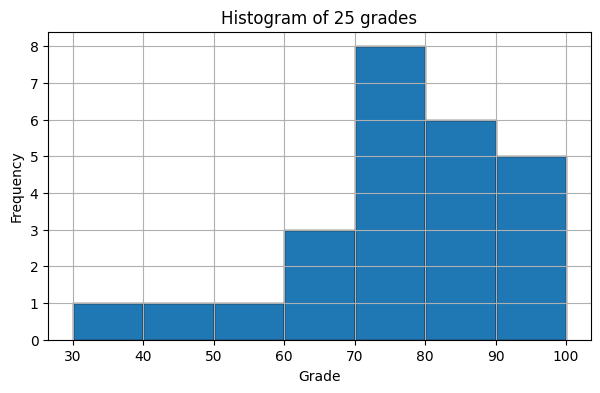

In [25]:
grades = np.array([60,72,90,95,77,97,58,85,72,80,47,67,
                   77,74,39,70,78,82,86,91,82,66,86,72,90])

counts, edges = np.histogram(grades, bins=[30,40,50,60,70,80,90,100])
for lo, hi, c in zip(edges[:-1], edges[1:], counts):
    print(f"{int(lo):>3}-{int(hi):<3}: {'#'*c} ({c})")

plt.hist(grades, bins=[30,40,50,60,70,80,90,100], edgecolor="black")
plt.xlabel("Grade"); plt.ylabel("Frequency"); plt.title("Histogram of 25 grades")
plt.show()

## 1.4 Normal (Gaussian) Distribution

The classic **bell curve**: symmetric about the mean, with values tapering off
equally in both directions. In a perfect normal distribution the mean, median and
mode coincide. Its probability density function (PDF) is

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}}\;
         e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}.$$

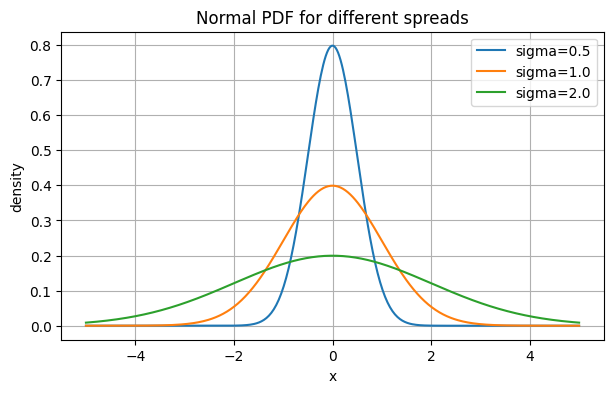

Within +/-1 sigma: 68.29%
Within +/-2 sigma: 95.43%
Within +/-3 sigma: 99.73%


In [26]:
def normal_pdf(x, mu=0.0, sigma=1.0):
    coeff = 1.0 / (sigma * np.sqrt(2 * np.pi))
    return coeff * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

xs = np.linspace(-5, 5, 400)
for sigma in (0.5, 1.0, 2.0):
    plt.plot(xs, normal_pdf(xs, 0, sigma), label=f"sigma={sigma}")
plt.title("Normal PDF for different spreads")
plt.xlabel("x"); plt.ylabel("density"); plt.legend()
plt.show()

# The famous 68 / 95 / 99.7 rule, verified by sampling
draws = rng.normal(0, 1, size=1_000_000)
for k in (1, 2, 3):
    inside = np.mean(np.abs(draws) < k) * 100
    print(f"Within +/-{k} sigma: {inside:.2f}%")

## 1.5 Skewness

Skewness measures **asymmetry**.

- **Negative (left) skew**: tail on the left, `mean < median < mode`.
- **Symmetric**: `mean = median = mode`.
- **Positive (right) skew**: tail on the right, `mean > median > mode`.

Sample skewness (Fisher–Pearson):
$$g_1 = \frac{n}{(n-1)(n-2)} \sum \left(\frac{x_i-\bar{x}}{s}\right)^3.$$

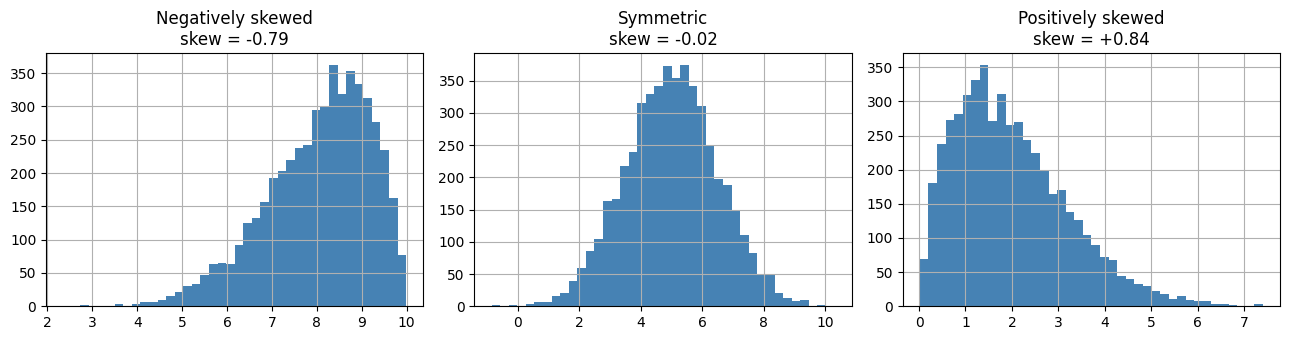

In [27]:
def skewness(x):
    n = x.size
    s = np.std(x, ddof=1)
    return n / ((n - 1) * (n - 2)) * np.sum(((x - x.mean()) / s) ** 3)

left  = rng.beta(8, 2, size=5000) * 10     # tail to the left  -> negative
sym   = rng.normal(5, 1.5, size=5000)      # symmetric         -> ~0
right = rng.beta(2, 8, size=5000) * 10     # tail to the right -> positive

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, d, name in zip(axes, (left, sym, right),
                       ("Negatively skewed", "Symmetric", "Positively skewed")):
    ax.hist(d, bins=40, color="steelblue")
    ax.set_title(f"{name}\nskew = {skewness(d):+.2f}")
plt.tight_layout(); plt.show()

## 1.6 Independence vs. Dependence & Correlation

- **Independent**: knowing one variable tells you *nothing* about the other.
- **Dependent**: one variable is linked to / influenced by the other.

**Correlation** (Pearson's $r$) measures the *strength and direction* of a
**linear** relationship, ranging from $-1$ to $+1$:

$$r = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}
            {\sqrt{\sum (x_i-\bar{x})^2 \sum (y_i-\bar{y})^2}}.$$

A crucial caveat (last panel below): $r=0$ does **not** mean "no relationship" —
only "no *linear* relationship". A perfect arch has $r\approx 0$.

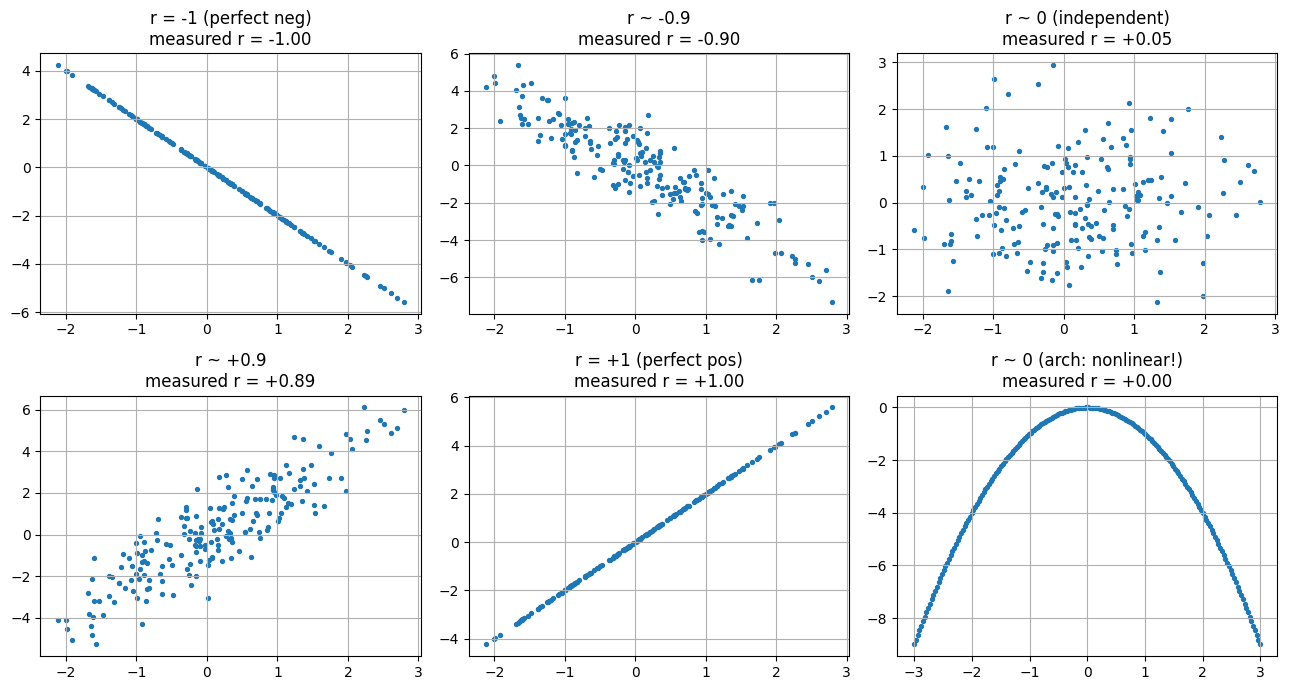

np.corrcoef r = 0.8890804856949993


In [28]:
def pearson_r(x, y):
    xc, yc = x - x.mean(), y - y.mean()
    return np.sum(xc * yc) / np.sqrt(np.sum(xc**2) * np.sum(yc**2))

n = 200
x = rng.normal(size=n)
datasets = {
    "r = -1 (perfect neg)" : (x, -2 * x),
    "r ~ -0.9"             : (x, -2 * x + rng.normal(0, 1.0, n)),
    "r ~ 0 (independent)"  : (x, rng.normal(size=n)),
    "r ~ +0.9"             : (x,  2 * x + rng.normal(0, 1.0, n)),
    "r = +1 (perfect pos)" : (x,  2 * x),
    "r ~ 0 (arch: nonlinear!)": (np.linspace(-3, 3, n), -(np.linspace(-3,3,n)**2)),
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (title, (xx, yy)) in zip(axes.ravel(), datasets.items()):
    ax.scatter(xx, yy, s=8)
    ax.set_title(f"{title}\nmeasured r = {pearson_r(xx, yy):+.2f}")
plt.tight_layout(); plt.show()

# numpy's built-in correlation matrix agrees with our formula
xx, yy = datasets["r ~ +0.9"]
print("np.corrcoef r =", np.corrcoef(xx, yy)[0, 1])

---
# Part 2 — Minimum Probability

## 2.1 Probability Fundamentals & Events

- **Sample space $\Omega$**: every possible outcome of an experiment.
- **Event $A$**: a subset of $\Omega$ (one or more outcomes).
- **Probability $P(A)$**: a number in $[0, 1]$; $0$ = impossible, $1$ = certain.

For equally likely outcomes, $P(A) = \dfrac{|A|}{|\Omega|}$.

In [29]:
omega = np.array([1, 2, 3, 4, 5, 6])     # rolling a fair die
event_even = omega[omega % 2 == 0]       # A = {2, 4, 6}

p_even = event_even.size / omega.size
print("Sample space:", omega)
print("Event 'even':", event_even)
print("P(even) =", p_even)

# Empirical check: simulate 100,000 rolls
rolls = rng.integers(1, 7, size=100_000)
print("Simulated  P(even) =", np.mean(rolls % 2 == 0))

Sample space: [1 2 3 4 5 6]
Event 'even': [2 4 6]
P(even) = 0.5
Simulated  P(even) = 0.49848


## 2.2 Conditional Probability

The probability of $A$ **given that** $B$ has occurred restricts the world to
outcomes where $B$ happens:

$$P(A\mid B) = \frac{P(A \cap B)}{P(B)}, \qquad P(B) > 0.$$

**Slide example:** draw one card from a 52-card deck.
$P(\text{King} \mid \text{Face card}) = \frac{4/52}{12/52} = \frac{4}{12} = \frac13$.

In [30]:
# Build a deck as (rank, suit). Ranks 11=J, 12=Q, 13=K.
ranks = np.arange(1, 14)
deck  = np.array([(r, s) for s in range(4) for r in ranks])

is_king = deck[:, 0] == 13
is_face = np.isin(deck[:, 0], [11, 12, 13])

p_king_and_face = np.mean(is_king & is_face)   # a King is always a face card
p_face          = np.mean(is_face)

print("P(King and Face) =", p_king_and_face, "= 4/52")
print("P(Face)          =", p_face,          "= 12/52")
print("P(King | Face)   =", p_king_and_face / p_face, "= 1/3")

P(King and Face) = 0.07692307692307693 = 4/52
P(Face)          = 0.23076923076923078 = 12/52
P(King | Face)   = 0.3333333333333333 = 1/3


## 2.3 Independence of Events

Two events are **independent** when one occurring does not change the probability
of the other:

$$P(A \cap B) = P(A)\,P(B) \qquad\Longleftrightarrow\qquad P(A \mid B) = P(A).$$

In [31]:
# Two independent dice. A = first die even, B = second die > 4.
d1 = rng.integers(1, 7, size=500_000)
d2 = rng.integers(1, 7, size=500_000)

pA  = np.mean(d1 % 2 == 0)
pB  = np.mean(d2 > 4)
pAB = np.mean((d1 % 2 == 0) & (d2 > 4))

print(f"P(A)        = {pA:.3f}")
print(f"P(B)        = {pB:.3f}")
print(f"P(A)*P(B)   = {pA*pB:.3f}")
print(f"P(A and B)  = {pAB:.3f}   -> matches, so A and B are independent")

P(A)        = 0.501
P(B)        = 0.333
P(A)*P(B)   = 0.167
P(A and B)  = 0.168   -> matches, so A and B are independent


## 2.4 Random Variables: Discrete vs. Continuous

A **random variable** $X$ maps outcomes to numbers (it is *stochastic*, unlike a
deterministic programming variable that holds a fixed value).

- **Discrete**: countable values (die roll, email count) — described by a
  **Probability Mass Function (PMF)**.
- **Continuous**: any value in an interval (height, time) — described by a
  **Probability Density Function (PDF)**.

In [32]:
# Discrete RV: a fair die. PMF gives an exact probability per value.
values = np.arange(1, 7)
pmf = np.full(6, 1/6)
print("Discrete PMF (die):", dict(zip(values, np.round(pmf, 3))))
print("PMF sums to:", pmf.sum())

# Continuous RV: for a PDF, P(exact value) = 0; probability = AREA under the curve.
xs = np.linspace(-4, 4, 1000)
density = normal_pdf(xs)
area = np.trapz(density, xs)     # total area under a PDF integrates to 1
print("\nArea under the normal PDF (should be ~1):", round(area, 4))

Discrete PMF (die): {1: 0.167, 2: 0.167, 3: 0.167, 4: 0.167, 5: 0.167, 6: 0.167}
PMF sums to: 0.9999999999999999

Area under the normal PDF (should be ~1): 0.9999


## 2.5 PMF, PDF, and CDF

The **Cumulative Distribution Function** $F(x) = P(X \le x)$ accumulates
probability. For discrete variables it is a staircase; for continuous variables it
is a smooth S-curve that climbs from 0 to 1.

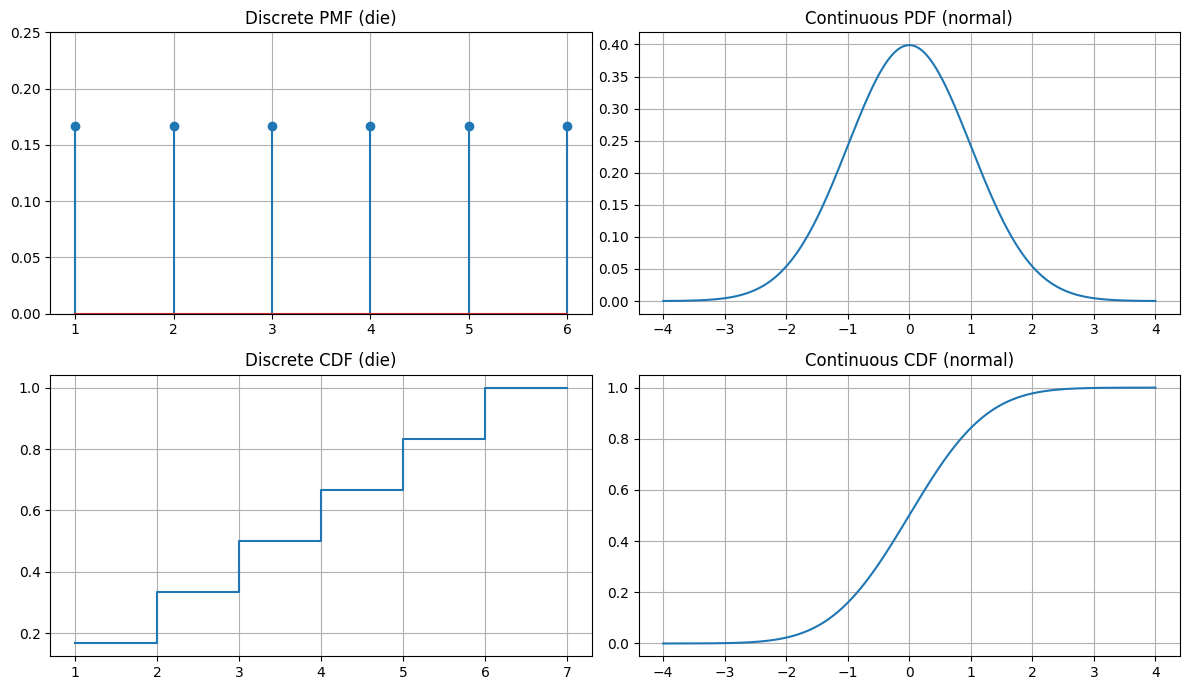

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# --- Discrete: die ---
axes[0,0].stem(values, pmf)
axes[0,0].set_title("Discrete PMF (die)"); axes[0,0].set_ylim(0, 0.25)
axes[1,0].step(np.append(values, 7), np.append(np.cumsum(pmf), 1), where="post")
axes[1,0].set_title("Discrete CDF (die)")

# --- Continuous: normal ---
axes[0,1].plot(xs, density)
axes[0,1].set_title("Continuous PDF (normal)")
cdf = np.cumsum(density) * (xs[1] - xs[0])     # numerical integral
axes[1,1].plot(xs, cdf)
axes[1,1].set_title("Continuous CDF (normal)")
plt.tight_layout(); plt.show()

## 2.6 Expected Value $E[X]$

The **long-run average** — the "centre of mass" of the distribution.

$$E[X] = \sum_x x\,P(X=x)\quad(\text{discrete})\qquad
   E[X] = \int_{-\infty}^{\infty} x\,f(x)\,dx\quad(\text{continuous})$$

**Slide example:** a game pays \$50 with probability 0.10 and \$0 otherwise.
$E[X] = 0.10(50) + 0.90(0) = \$5$. The **Law of Large Numbers** says the running
average of many plays converges to this expected value.

E[X] = 5.0


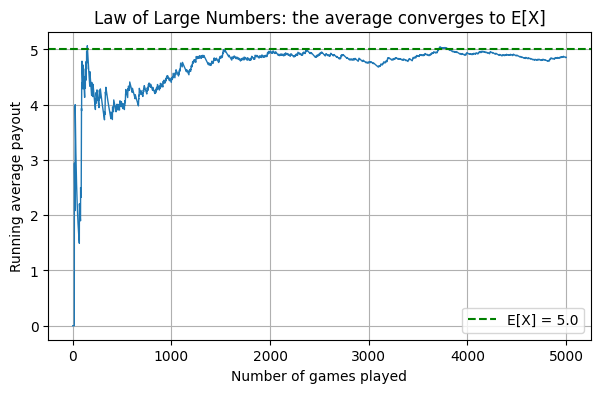

In [34]:
payouts = np.array([50, 0])
probs   = np.array([0.10, 0.90])
EX = np.sum(payouts * probs)
print("E[X] =", EX)

# Simulate playing the game 5,000 times and track the running average.
plays = rng.choice(payouts, size=5000, p=probs)
running_avg = np.cumsum(plays) / np.arange(1, plays.size + 1)

plt.plot(running_avg, lw=1)
plt.axhline(EX, color="green", ls="--", label=f"E[X] = {EX}")
plt.xlabel("Number of games played"); plt.ylabel("Running average payout")
plt.title("Law of Large Numbers: the average converges to E[X]")
plt.legend(); plt.show()

## 2.7 Variance of a Random Variable

$$\mathrm{Var}(X) = E\big[(X - E[X])^2\big] = E[X^2] - (E[X])^2.$$

The two forms are algebraically identical; the second ("computational") form is
often easier to evaluate.

In [35]:
x_sq = payouts ** 2
var_def  = np.sum((payouts - EX) ** 2 * probs)     # definition
var_comp = np.sum(x_sq * probs) - EX ** 2          # E[X^2] - (E[X])^2

print("Var(X) by definition      :", var_def)
print("Var(X) computational form :", var_comp)
print("Std dev                   :", np.sqrt(var_def))

Var(X) by definition      : 225.0
Var(X) computational form : 225.0
Std dev                   : 15.0


## 2.8 Core Distributions

| Distribution | Use case | $E[X]$ | $\mathrm{Var}(X)$ |
|---|---|---|---|
| **Bernoulli** | one trial, two outcomes | $p$ | $p(1-p)$ |
| **Binomial** | #successes in $n$ trials | $np$ | $np(1-p)$ |
| **Categorical** | one of $k$ categories | — | — |
| **Gaussian** | continuous bell curve | $\mu$ | $\sigma^2$ |

In [36]:
# --- Bernoulli(p): a single biased coin ---
p = 0.3
bern = (rng.random(100_000) < p).astype(int)
print("Bernoulli  p=0.3 -> E[X] theory:", p, "| empirical:", bern.mean().round(4))
print("            Var theory:", round(p*(1-p), 4), "| empirical:", bern.var().round(4))

# --- Binomial(n, p): successes in n Bernoulli trials ---
n, p = 10, 0.5
binom = rng.binomial(n, p, size=100_000)
print(f"\nBinomial n=10,p=0.5 -> E[X] theory: {n*p} | empirical: {binom.mean():.3f}")
print(f"                       Var theory: {n*p*(1-p)} | empirical: {binom.var():.3f}")

# --- Categorical / Multinoulli: a weighted 4-sided spinner ---
cat_p = np.array([0.30, 0.25, 0.35, 0.10])
cat = rng.choice(4, size=100_000, p=cat_p)
freqs = np.bincount(cat) / cat.size
print("\nCategorical target probs:", cat_p)
print("Categorical empirical    :", freqs.round(3))

Bernoulli  p=0.3 -> E[X] theory: 0.3 | empirical: 0.3003
            Var theory: 0.21 | empirical: 0.2101

Binomial n=10,p=0.5 -> E[X] theory: 5.0 | empirical: 4.992
                       Var theory: 2.5 | empirical: 2.504

Categorical target probs: [0.3  0.25 0.35 0.1 ]
Categorical empirical    : [0.3   0.249 0.351 0.1  ]


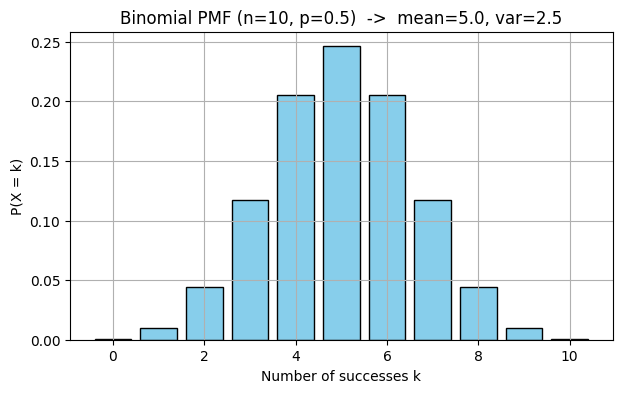

In [37]:
# Visualise the binomial PMF from its formula:  P(X=k) = C(n,k) p^k (1-p)^(n-k)
from math import comb
ks = np.arange(0, n + 1)
binom_pmf = np.array([comb(n, k) * p**k * (1 - p)**(n - k) for k in ks])

plt.bar(ks, binom_pmf, color="skyblue", edgecolor="black")
plt.xlabel("Number of successes k"); plt.ylabel("P(X = k)")
plt.title(f"Binomial PMF (n={n}, p={p})  ->  mean={n*p}, var={n*p*(1-p)}")
plt.show()

## 2.9 Bayes' Rule

Update a belief when new evidence arrives:

$$P(A\mid B) = \frac{P(B\mid A)\,P(A)}{P(B)}.$$

- $P(A\mid B)$ — **posterior** (belief after evidence)
- $P(B\mid A)$ — **likelihood**
- $P(A)$ — **prior** (belief before evidence)
- $P(B)$ — **marginal** (total probability of the evidence)

**Slide example (spam filter).** Prior $P(\text{Spam})=0.40$; likelihood
$P(\text{"Free"}\mid\text{Spam})=0.80$; $P(\text{"Free"}\mid\text{Not Spam})=0.10$.
An email contains "Free" — how likely is it spam?

In [38]:
p_spam            = 0.40
p_free_given_spam = 0.80
p_free_given_ham  = 0.10
p_ham             = 1 - p_spam

# Step 1 — marginal P("Free") via the law of total probability (the denominator)
p_free = p_free_given_spam * p_spam + p_free_given_ham * p_ham
print("Step 1  P('Free') =", round(p_free, 3))   # 0.38

# Step 2 — Bayes' rule
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print("Step 2  P(Spam | 'Free') =", round(p_spam_given_free, 3), f"(~{p_spam_given_free*100:.1f}%)")

Step 1  P('Free') = 0.38
Step 2  P(Spam | 'Free') = 0.842 (~84.2%)


In [39]:
# Sanity check by simulation: generate 1,000,000 emails and count.
N = 1_000_000
is_spam = rng.random(N) < p_spam
has_free = np.where(is_spam,
                    rng.random(N) < p_free_given_spam,
                    rng.random(N) < p_free_given_ham)

emails_with_free = is_spam[has_free]
print("Simulated P(Spam | 'Free') =", round(emails_with_free.mean(), 3))

Simulated P(Spam | 'Free') = 0.843


---
# Part 3 — Linear Algebra: The Building Blocks of Data

## 3.1 Scalars, Vectors, Matrices, Tensors

| Object | Dimensions | Example | NumPy shape |
|---|---|---|---|
| **Scalar** | 0-D | a learning rate `0.01` | `()` |
| **Vector** | 1-D | a row of features | `(n,)` |
| **Matrix** | 2-D | a grayscale image | `(m, n)` |
| **Tensor** | n-D | a batch of RGB images | `(s, h, w, c)` |

Scalars, vectors and matrices are all just special cases of tensors.

In [40]:
scalar = np.array(0.01)                         # 0-D
vector = np.array([1.0, 2.0, 3.0])              # 1-D
matrix = np.array([[1, 2], [3, 4]])             # 2-D
tensor = rng.integers(0, 256, size=(8, 32, 32, 3))  # 4-D: batch of 8 RGB images

for name, obj in [("scalar", scalar), ("vector", vector),
                  ("matrix", matrix), ("tensor", tensor)]:
    print(f"{name:7} ndim={obj.ndim}  shape={obj.shape}")

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=4  shape=(8, 32, 32, 3)


## 3.2 Matrix Addition

Element-by-element. Both matrices **must have the same shape**.

In [41]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[1, 0], [0, 1]])
print("A + B =\n", A + B)

A + B =
 [[2 2]
 [3 5]]


## 3.3 The Dot Product

Takes two equal-length vectors and returns a single **scalar**. Geometrically it
measures how much two vectors point the same way:

$$\mathbf{a}\cdot\mathbf{b} = \sum_i a_i b_i = \|\mathbf{a}\|\,\|\mathbf{b}\|\cos\theta.$$

This is the core of "similarity" — e.g. comparing two face-embedding vectors.

In [42]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])

print("Manual sum a_i*b_i :", np.sum(a * b))
print("np.dot             :", np.dot(a, b))
print("@ operator         :", a @ b)

# Recover the angle between two vectors via the geometric form.
def cosine_similarity(u, v):
    return (u @ v) / (np.linalg.norm(u) * np.linalg.norm(v))

cos_t = cosine_similarity(a, b)
print(f"\ncosine similarity = {cos_t:.4f}  ->  angle = {np.degrees(np.arccos(cos_t)):.2f} deg")
print("Identical-direction vectors -> similarity:", cosine_similarity(a, 2*a))
print("Orthogonal vectors          -> similarity:", cosine_similarity(np.array([1,0]), np.array([0,1])))

Manual sum a_i*b_i : 32.0
np.dot             : 32.0
@ operator         : 32.0

cosine similarity = 0.9746  ->  angle = 12.93 deg
Identical-direction vectors -> similarity: 1.0
Orthogonal vectors          -> similarity: 0.0


## 3.4 Vector–Matrix Multiplication

$\mathbf{y} = \mathbf{W}\mathbf{x}$: each entry of the output is the dot product of
one **row** of $\mathbf{W}$ with the vector $\mathbf{x}$. Shapes: $(m,n)\times(n,)=(m,)$.

**Slide example:** $\mathbf{W}=\begin{bmatrix}1&2\\3&4\end{bmatrix}$,
$\mathbf{x}=\begin{bmatrix}5\\6\end{bmatrix} \Rightarrow
\mathbf{y}=\begin{bmatrix}17\\39\end{bmatrix}$.

In [43]:
W = np.array([[1, 2], [3, 4]])
x = np.array([5, 6])

y = W @ x
print("y = W @ x =", y)
print("Row 0 dot x:", W[0] @ x, " (= 1*5 + 2*6 = 17)")
print("Row 1 dot x:", W[1] @ x, " (= 3*5 + 4*6 = 39)")

y = W @ x = [17 39]
Row 0 dot x: 17  (= 1*5 + 2*6 = 17)
Row 1 dot x: 39  (= 3*5 + 4*6 = 39)


## 3.5 Geometric Transformations: Rotation & Scaling

Matrices *are* transformations. Two classics:

$$\text{Rotation by }\theta:\;
\mathbf{R}=\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix}
\qquad
\text{Scaling:}\;
\mathbf{S}=\begin{bmatrix}s_x & 0\\ 0 & s_y\end{bmatrix}$$

original : [3. 1.]
rotated  : [-1.  3.]
scaled   : [6.  0.5]


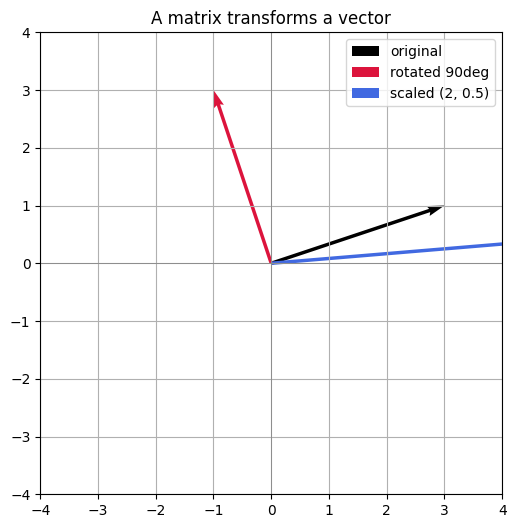

In [44]:
def rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

v = np.array([3.0, 1.0])
R = rotation_matrix(np.deg2rad(90))     # rotate 90 degrees
S = np.array([[2.0, 0.0], [0.0, 0.5]])  # stretch x by 2, squash y by half

v_rot   = R @ v
v_scaled = S @ v
print("original :", v)
print("rotated  :", v_rot.round(4))
print("scaled   :", v_scaled)

fig, ax = plt.subplots(figsize=(6, 6))
for vec, color, label in [(v,"black","original"),
                          (v_rot,"crimson","rotated 90deg"),
                          (v_scaled,"royalblue","scaled (2, 0.5)")]:
    ax.quiver(0, 0, vec[0], vec[1], angles="xy", scale_units="xy",
              scale=1, color=color, label=label)
ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.axhline(0, color="grey", lw=0.5)
ax.axvline(0, color="grey", lw=0.5); ax.set_aspect("equal"); ax.legend()
ax.set_title("A matrix transforms a vector")
plt.show()

## 3.6 Matrix Multiplication

The **composition** of two linear transformations. To compute $\mathbf{C}=\mathbf{A}\mathbf{B}$,
take dot products of the **rows of $\mathbf{A}$** with the **columns of $\mathbf{B}$**.

**Rule:** inner dimensions must match: $(m\times n)\cdot(n\times p) = (m\times p)$.

In [45]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])          # shape (2, 3)
B = np.array([[7,  8],
              [9, 10],
              [11, 12]])           # shape (3, 2)

C = A @ B                          # (2,3)@(3,2) -> (2,2)
print("A shape:", A.shape, " B shape:", B.shape, " -> C shape:", C.shape)
print("C = A @ B =\n", C)

# Composition is order-sensitive: applying R then S != S then R
print("\nR then S:\n", (S @ R).round(3))
print("S then R:\n", (R @ S).round(3))

A shape: (2, 3)  B shape: (3, 2)  -> C shape: (2, 2)
C = A @ B =
 [[ 58  64]
 [139 154]]

R then S:
 [[ 0.  -2. ]
 [ 0.5  0. ]]
S then R:
 [[ 0.  -0.5]
 [ 2.   0. ]]


## 3.7 The Linear Equation $\mathbf{y} = \mathbf{W}\mathbf{x} + \mathbf{b}$

A matrix multiply plus a **bias** vector — this single line is the heart of every
neural-network layer.

In [46]:
W = rng.normal(size=(3, 4))   # maps a 4-D input to a 3-D output
x = rng.normal(size=4)
b = np.array([0.5, -0.5, 1.0])

y = W @ x + b
print("input  x shape:", x.shape)
print("weight W shape:", W.shape)
print("output y shape:", y.shape, "->", y.round(3))

input  x shape: (4,)
weight W shape: (3, 4)
output y shape: (3,) -> [ 0.114  1.886 -1.806]


## 3.8 A Neural Network = Nested Linear Equations + Nonlinearity

Stacking $\mathbf{W}\mathbf{x}+\mathbf{b}$ layers with a nonlinear *activation*
$\sigma$ in between yields

$$F(x) = w_3^{\!\top}\sigma\!\big(W_2^{\!\top}\sigma(W_1^{\!\top}x + b_1) + b_2\big) + b_3.$$

The activation is what lets the network model *nonlinear* relationships. Here is a
full forward pass implemented with nothing but NumPy.

In [47]:
def relu(z):
    return np.maximum(0, z)

# A 3 -> 4 -> 4 -> 1 network (matches the slide's architecture).
W1, b1 = rng.normal(size=(4, 3)), rng.normal(size=4)
W2, b2 = rng.normal(size=(4, 4)), rng.normal(size=4)
W3, b3 = rng.normal(size=(1, 4)), rng.normal(size=1)

def forward(x):
    h1 = relu(W1 @ x + b1)     # hidden layer 1
    h2 = relu(W2 @ h1 + b2)    # hidden layer 2
    return W3 @ h2 + b3        # output

x_in = np.array([0.5, -1.2, 2.0])
print("network output F(x) =", forward(x_in).round(4))

network output F(x) = [2.932]


## 3.9 Norms and Distances

A **norm** measures the "size" of a vector — critical for quantifying *loss* (how
far a prediction is from reality).

- **$L^1$ (Manhattan):** $\sum_i |x_i|$
- **$L^2$ (Euclidean):** $\sqrt{\sum_i x_i^2}$ — the straight-line distance.

**Slide example:** $a=\begin{bmatrix}4\\2\end{bmatrix}$, $b=\begin{bmatrix}3\\1\end{bmatrix}
\Rightarrow \|a-b\|_2 = \sqrt{2}$.

In [48]:
a = np.array([4.0, 2.0])
b = np.array([3.0, 1.0])
diff = a - b

l1 = np.sum(np.abs(diff))
l2 = np.sqrt(np.sum(diff ** 2))
print("L1 (Manhattan) distance:", l1)
print("L2 (Euclidean) distance:", round(l2, 4), " = sqrt(2)")

# numpy.linalg.norm computes both via the `ord` argument
print("np.linalg.norm L1:", np.linalg.norm(diff, ord=1))
print("np.linalg.norm L2:", round(np.linalg.norm(diff, ord=2), 4))

L1 (Manhattan) distance: 2.0
L2 (Euclidean) distance: 1.4142  = sqrt(2)
np.linalg.norm L1: 2.0
np.linalg.norm L2: 1.4142


---
# Part 4 — Vector Calculus: The Engine of Machine Learning

## 4.1 Functions, Graphs, and the Loss Landscape

A function $y=f(x)$ maps inputs to outputs. In ML the key function is the **loss**:
plot every weight combination on the input axes and the resulting error on the
output axis, and you get a *landscape* of hills (high error) and valleys (low
error). **Learning = finding the lowest valley.**

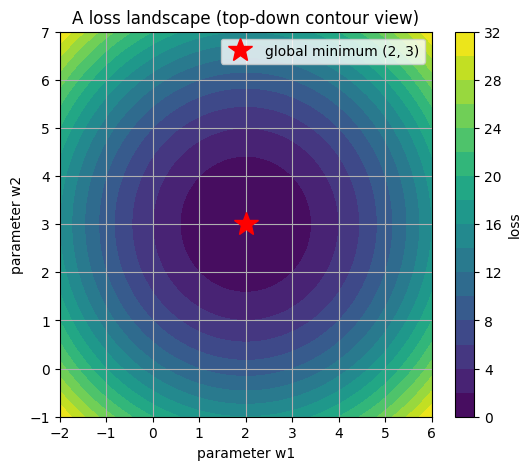

In [49]:
# A simple 2-parameter loss surface: L(w1, w2) = (w1-2)^2 + (w2-3)^2
w1 = np.linspace(-2, 6, 100)
w2 = np.linspace(-1, 7, 100)
G1, G2 = np.meshgrid(w1, w2)
loss = (G1 - 2) ** 2 + (G2 - 3) ** 2

fig, ax = plt.subplots(figsize=(6, 5))
cs = ax.contourf(G1, G2, loss, levels=20, cmap="viridis")
ax.plot(2, 3, "r*", markersize=18, label="global minimum (2, 3)")
ax.set_xlabel("parameter w1"); ax.set_ylabel("parameter w2")
ax.set_title("A loss landscape (top-down contour view)"); ax.legend()
plt.colorbar(cs, label="loss"); plt.show()

## 4.2 Derivatives: The Slope

The derivative $f'(x)=\frac{df}{dx}$ is the **instantaneous rate of change** — the
slope of the tangent line. ML intuition: standing on the loss hill, it tells you
how steep the ground is and which way is downhill.

**Slide example:** $f(x)=x^2-4x+5 \Rightarrow f'(x)=2x-4$ (zero at the minimum $x=2$).

x=-1: analytical f'= -6  numerical f'=-6.0000
x= 0: analytical f'= -4  numerical f'=-4.0000
x= 2: analytical f'=  0  numerical f'=0.0000
x= 5: analytical f'=  6  numerical f'=6.0000


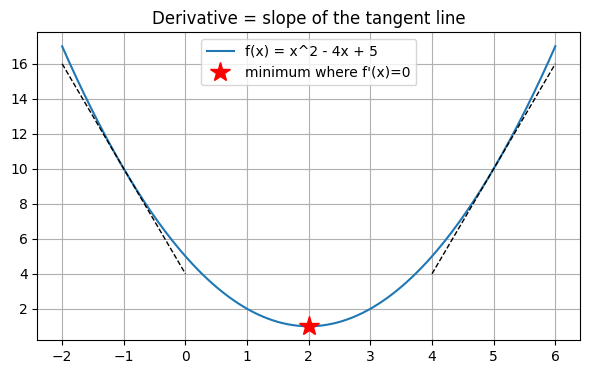

In [50]:
f      = lambda x: x**2 - 4*x + 5
f_prime = lambda x: 2*x - 4          # the analytical derivative

# Numerical derivative (finite differences) to confirm the analytical one.
def numerical_derivative(func, x, h=1e-6):
    return (func(x + h) - func(x - h)) / (2 * h)

for x0 in [-1, 0, 2, 5]:
    print(f"x={x0:>2}: analytical f'={f_prime(x0):>3}  "
          f"numerical f'={numerical_derivative(f, x0):.4f}")

xs = np.linspace(-2, 6, 200)
plt.plot(xs, f(xs), label="f(x) = x^2 - 4x + 5")
plt.plot(2, f(2), "r*", markersize=15, label="minimum where f'(x)=0")
for x0 in [-1, 5]:
    slope = f_prime(x0)
    tx = np.linspace(x0 - 1, x0 + 1, 10)
    plt.plot(tx, f(x0) + slope * (tx - x0), "k--", lw=1)
plt.legend(); plt.title("Derivative = slope of the tangent line"); plt.show()

## 4.3 Partial Derivatives & The Gradient

Real models have millions of weights. A **partial derivative**
$\frac{\partial f}{\partial x_i}$ measures how the loss changes if you nudge **one**
weight while freezing the rest. The **gradient** $\nabla f$ packages all the
partials into a vector that points in the direction of **steepest ascent** (uphill).

**Slide example:** $f(x,y)=x^2+y^2 \Rightarrow \nabla f = \begin{bmatrix}2x\\2y\end{bmatrix}$,
so $\nabla f(1,-1)=\begin{bmatrix}2\\-2\end{bmatrix}$.

Gradient at (1, -1): [ 2 -2]


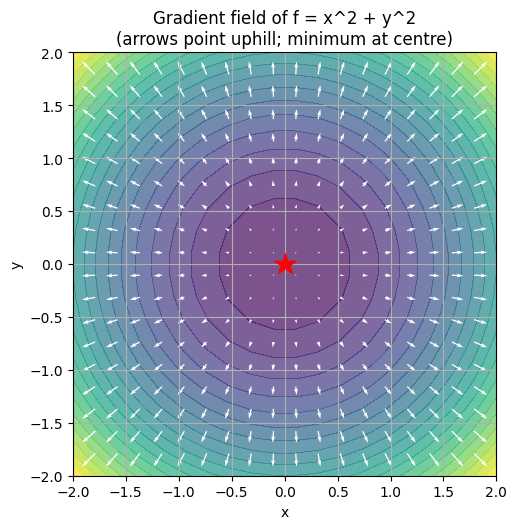

In [51]:
f2     = lambda x, y: x**2 + y**2
grad_f = lambda x, y: np.array([2*x, 2*y])

print("Gradient at (1, -1):", grad_f(1, -1))   # [2, -2]

# Visualise the field of gradient vectors over the contour map.
gx = np.linspace(-2, 2, 20)
gy = np.linspace(-2, 2, 20)
GX, GY = np.meshgrid(gx, gy)
U, V = 2*GX, 2*GY                                # gradient components

fig, ax = plt.subplots(figsize=(6, 5.5))
ax.contourf(GX, GY, f2(GX, GY), levels=20, cmap="viridis", alpha=0.7)
ax.quiver(GX, GY, U, V, color="white")          # arrows point uphill (steepest ascent)
ax.plot(0, 0, "r*", markersize=16)
ax.set_title("Gradient field of f = x^2 + y^2\n(arrows point uphill; minimum at centre)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_aspect("equal")
plt.show()

## 4.4 The Chain Rule — the engine of backpropagation

To differentiate nested functions, multiply the derivatives of each layer:

$$\frac{dy}{dx} = \frac{dy}{du}\cdot\frac{du}{dx}.$$

**Slide example:** $y=(3x+2)^2$. Let $u=3x+2$, so $y=u^2$. Then
$\frac{dy}{du}=2u$ and $\frac{du}{dx}=3$, giving $\frac{dy}{dx}=6u=6(3x+2)$.

In [52]:
y       = lambda x: (3*x + 2)**2
dy_dx   = lambda x: 6 * (3*x + 2)     # chain-rule result

for x0 in [0, 1, 2]:
    print(f"x={x0}: chain-rule dy/dx={dy_dx(x0):>3}  "
          f"numerical={numerical_derivative(y, x0):.4f}")

x=0: chain-rule dy/dx= 12  numerical=12.0000
x=1: chain-rule dy/dx= 30  numerical=30.0000
x=2: chain-rule dy/dx= 48  numerical=48.0000


### Putting it together: Gradient Descent

The whole point of gradients is to *minimise loss*. Repeatedly step **opposite** to
the gradient (downhill):

$$w \leftarrow w - \eta\,\nabla f(w),$$

where $\eta$ is the **learning rate**. Below we minimise $f(x)=x^2-4x+5$ from
scratch and watch it roll into the valley at $x=2$.

Started at x=8.0, converged to x=2.0008 (true minimum = 2.0)


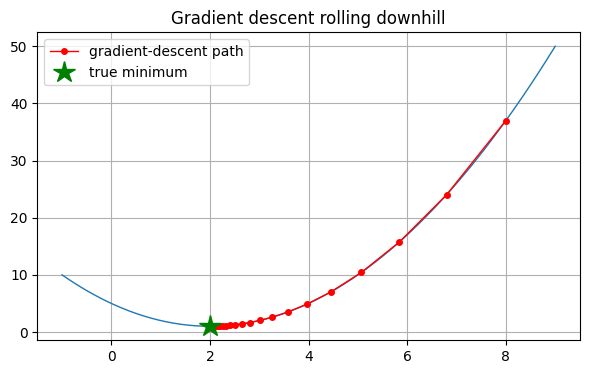

In [53]:
x_curr = 8.0          # bad starting guess
lr = 0.1              # learning rate (eta)
history = [x_curr]

for step in range(40):
    grad = f_prime(x_curr)        # slope at current point
    x_curr = x_curr - lr * grad   # step downhill
    history.append(x_curr)

history = np.array(history)
print(f"Started at x=8.0, converged to x={x_curr:.4f} (true minimum = 2.0)")

xs = np.linspace(-1, 9, 200)
plt.plot(xs, f(xs), lw=1)
plt.plot(history, f(history), "ro-", ms=4, lw=1, label="gradient-descent path")
plt.plot(2, f(2), "g*", ms=16, label="true minimum")
plt.title("Gradient descent rolling downhill"); plt.legend(); plt.show()

## 4.5 Convex vs. Non-Convex

- **Convex**: a single bowl. Gradient descent is *guaranteed* to reach the global
  minimum.
- **Non-convex**: a rugged range with **local minima** (false bottoms) and
  **saddle points** (flat spots that aren't valleys). Deep-network loss surfaces
  are wildly non-convex — which is why advanced optimisers (Adam, momentum) exist
  to carry enough "speed" to escape shallow local minima.

Below, the **same** gradient-descent code lands in **different** places on a
non-convex curve depending on where it starts — the core difficulty of training.

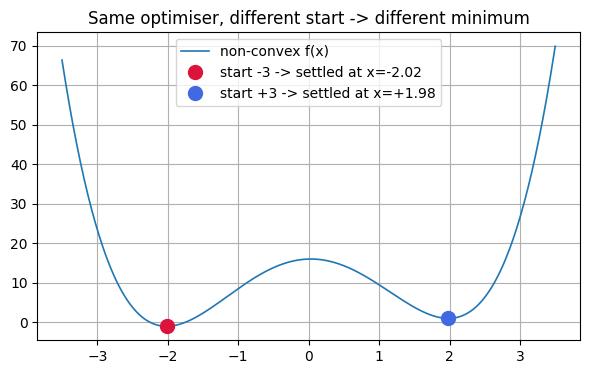

In [54]:
# A bumpy 1-D function with several minima.
g       = lambda x: x**4 - 8*x**2 + 0.5*x + 16
g_prime = lambda x: 4*x**3 - 16*x + 0.5

def descend(start, lr=0.01, steps=200):
    x = start
    for _ in range(steps):
        x -= lr * g_prime(x)
    return x

xs = np.linspace(-3.5, 3.5, 400)
plt.plot(xs, g(xs), lw=1.2, label="non-convex f(x)")
for start, color in [(-3.0, "crimson"), (3.0, "royalblue")]:
    end = descend(start)
    plt.plot(end, g(end), "o", color=color, ms=10,
             label=f"start {start:+.0f} -> settled at x={end:+.2f}")
plt.title("Same optimiser, different start -> different minimum")
plt.legend(); plt.show()

---
## Summary

You have now implemented, with nothing but NumPy:

- **Statistics** — sampling and inference; mean / median / mode; variance and std
  (population vs. sample via `ddof`); percentiles; histograms; the normal curve and
  the 68-95-99.7 rule; skewness; correlation (and why $r=0\ne$ "no relationship").
- **Probability** — sample spaces and events; conditional probability and
  independence; discrete vs. continuous random variables; PMF / PDF / CDF; expected
  value and the Law of Large Numbers; variance; the Bernoulli, binomial,
  categorical and Gaussian distributions; and Bayes' rule for updating beliefs.
- **Linear algebra** — scalars / vectors / matrices / tensors; addition, dot
  products, matrix multiplication; rotation and scaling transforms; the layer
  equation $\mathbf{y}=\mathbf{W}\mathbf{x}+\mathbf{b}$; a full neural-network
  forward pass; and $L^1$ / $L^2$ norms.
- **Vector calculus** — loss landscapes; derivatives (analytical vs. numerical);
  partial derivatives and gradients; the chain rule behind backpropagation;
  gradient descent from scratch; and why convexity matters.

These are the minimal mathematical foundations behind every model in the rest of
the program. **Next step:** swap the toy functions here for real loss functions and
real data, and the same machinery scales all the way up to large neural networks.